# Моделирование и финальное предсказание

В этом ноутбуке сравниваются несколько вариантов кластеризации без учителя, выбирается итоговая композиция и создаётся файл `submission.csv`.

## План моделирования

1. Построить признаки тем же воспроизводимым способом.
2. Получить базовую PCA/PSD-разметку.
3. Проверить несколько наборов гиперпараметров.
4. Сравнить GMM-модели на разных признаках.
5. Сформировать итоговый файл отправки.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import RobustScaler

from final_solution import (
    RANDOM_STATE,
    apply_perm_120,
    build_base_features,
    build_features,
    labels_from_ensemble,
    labels_from_gmm2,
    load_raw,
    make_final_submission,
    pca_boundary_score,
    rolling_psd_residual,
)

sns.set_theme(style="whitegrid")
DATA_PATH = Path("Run200_Wave_0_1.txt")

## Подготовка признаков

Признаки строятся из исходных сигналов заново, поэтому результат не зависит от заранее сохранённых промежуточных таблиц.

In [2]:
metadata, signals = load_raw(DATA_PATH)
features = build_features(signals, metadata)
base_features = build_base_features(signals)

print(features.shape)
display(features.head())

(23479, 20)


,log_charge,log_charge_main,log_peak,peak,peak_idx,psd_fixed,psd_rel,fast_rel,centroid,noise,baseline,expected_frac,meta_1,meta_2,shape_pc_1,shape_pc_2,shape_pc_3,shape_pc_4,shape_pc_5,shape_pc_6
0,8.399760,8.339262,6.023932,412.2,150,0.191451,0.166860,0.833140,168.992351,2.760724,14820.0,0.889928,357.0,113.0,1.546044,1.149579,1.331743,0.659315,0.440216,-1.202430
1,9.433084,9.402447,7.324490,1516.0,151,0.077077,0.062566,0.937434,160.659437,2.674520,14823.0,0.931209,740.0,359.0,-3.366461,-0.372735,0.469710,-0.342392,-0.200589,-0.109361
2,9.742203,9.720526,7.646449,2092.2,151,0.056992,0.047125,0.952875,158.615805,2.455592,14822.0,0.950839,162.0,499.0,-3.955678,-0.358551,0.304448,-0.489713,-0.411443,0.235406
3,8.482602,8.412499,6.130792,458.8,150,0.184510,0.155623,0.844377,171.333195,2.745906,14823.0,0.856778,841.0,123.0,1.482258,0.883148,0.298995,-0.525782,0.278501,-0.573942
4,9.365890,9.348623,7.275034,1442.8,151,0.056497,0.042131,0.957869,157.112994,2.695044,14821.0,0.961095,412.0,348.0,-4.160858,-0.416203,1.305444,0.050730,0.030377,0.374794


## Метрики сравнения

Так как истинные классы в обучающей части не даны, для сравнения используются внутренние метрики кластеризации: Silhouette, Calinski-Harabasz и Davies-Bouldin.

In [3]:
eval_columns = ["log_charge", "log_peak", "psd_rel", "centroid", "shape_pc_1", "shape_pc_2", "shape_pc_3"]
eval_matrix = RobustScaler().fit_transform(features[eval_columns])


def clustering_metrics(labels, matrix):
    sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(matrix), 6000, replace=False)
    return {
        "Silhouette": silhouette_score(matrix[sample_idx], labels[sample_idx]),
        "Calinski-Harabasz": calinski_harabasz_score(matrix, labels),
        "Davies-Bouldin": davies_bouldin_score(matrix, labels),
    }

## Базовая PCA/PSD-модель и подбор порогов

Базовая модель объединяет геометрию облака `log_charge`/`log_peak` и остаток PSD после сглаживания по энергии. Пороговые квантили отвечают за размер неоднозначного кластера.

In [4]:
pca_score = pca_boundary_score(base_features)
psd_residual = rolling_psd_residual(base_features)

grid_rows = []
for pca_quantile in [0.29, 0.31, 0.33, 0.35]:
    for psd_quantile in [0.29, 0.31, 0.33, 0.35]:
        raw_labels = labels_from_ensemble(pca_score, psd_residual, pca_quantile, psd_quantile)
        labels = apply_perm_120(raw_labels)
        row = {
            "model": "PCA/PSD",
            "pca_quantile": pca_quantile,
            "psd_quantile": psd_quantile,
            "cluster_2_share": float((labels == 2).mean()),
        }
        row.update(clustering_metrics(labels, eval_matrix))
        grid_rows.append(row)

base_grid = pd.DataFrame(grid_rows).sort_values("Silhouette", ascending=False)
display(base_grid.head(10))

,model,pca_quantile,psd_quantile,cluster_2_share,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,PCA/PSD,0.29,0.29,0.256910,0.097258,2774.090428,2.705072
8,PCA/PSD,0.33,0.29,0.242685,0.095830,2808.983303,2.627174
4,PCA/PSD,0.31,0.29,0.249713,0.095744,2780.066397,2.669300
12,PCA/PSD,0.35,0.29,0.235231,0.094939,2820.980848,2.589311
1,PCA/PSD,0.29,0.31,0.245837,0.094194,2761.353793,2.667458
9,PCA/PSD,0.33,0.31,0.232122,0.093191,2800.204657,2.591553
5,PCA/PSD,0.31,0.31,0.238852,0.092947,2769.683325,2.632215
13,PCA/PSD,0.35,0.31,0.225052,0.092521,2813.423986,2.555268
2,PCA/PSD,0.29,0.33,0.234380,0.091328,2741.756496,2.631232
10,PCA/PSD,0.33,0.33,0.221389,0.090520,2783.518421,2.558092


### Вывод по базовой модели

PCA/PSD-подход даёт интерпретируемую первичную разметку и явно выделяет неоднозначную область. Поэтому он используется как основа финальной композиции.

## GMM-модели на разных наборах признаков

GMM сравнивается на нескольких наборах признаков: физические параметры импульса, PCA-компоненты формы и смешанный набор. Доля неопределённых событий регулируется параметром `uncertain_fraction`.

In [5]:
feature_sets = {
    "shape_phys_u44": (["shape_pc_1", "shape_pc_2", "shape_pc_3", "log_charge", "log_peak", "psd_rel", "centroid"], 0.44),
    "shape_phys_u46": (["shape_pc_1", "shape_pc_2", "shape_pc_3", "log_charge", "log_peak", "psd_rel", "centroid"], 0.46),
    "shape_phys_u48": (["shape_pc_1", "shape_pc_2", "shape_pc_3", "log_charge", "log_peak", "psd_rel", "centroid"], 0.48),
    "shape4_u46": (["shape_pc_1", "shape_pc_2", "shape_pc_3", "shape_pc_4", "log_charge", "psd_rel"], 0.46),
    "phys6_u46": (["log_charge", "log_peak", "psd_rel", "psd_fixed", "centroid", "expected_frac"], 0.46),
}

model_labels = {}
comparison_rows = []
base_labels = apply_perm_120(labels_from_ensemble(pca_score, psd_residual, 0.33, 0.31))
row = {"model": "PCA/PSD baseline"}
row.update(clustering_metrics(base_labels, eval_matrix))
comparison_rows.append(row)

for name, (columns, uncertain_fraction) in feature_sets.items():
    labels = labels_from_gmm2(features, columns, uncertain_fraction)
    model_labels[name] = labels
    row = {"model": name}
    row.update(clustering_metrics(labels, eval_matrix))
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows).sort_values("Silhouette", ascending=False)
display(comparison)

,model,Silhouette,Calinski-Harabasz,Davies-Bouldin
2,shape_phys_u46,0.212405,10689.896958,1.496429
1,shape_phys_u44,0.211508,10687.031927,1.517532
3,shape_phys_u48,0.210678,10615.125053,1.477273
4,shape4_u46,0.206999,10471.539699,1.486291
5,phys6_u46,0.206192,10482.170881,1.526881
0,PCA/PSD baseline,0.093191,2800.204657,2.591553


## Финальная композиция

Итоговая модель не заменяет базовую разметку целиком. GMM используется как локальное уточнение для областей, где форма сигнала лучше описывается вероятностной моделью.

In [6]:
submission, diagnostic = make_final_submission()
submission.to_csv("submission.csv", index=False)
diagnostic.to_csv("final_features_with_clusters.csv", index=False)

display(submission.head())
display(submission["cluster"].value_counts().sort_index())

,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,0


cluster
0    8853
1    9176
2    5450
Name: count, dtype: int64

## Интерпретация кластеров

Финальные кластеры сравниваются по средним значениям основных физических признаков. Это позволяет проверить, что группы отличаются не только номером метки, но и формой/энергией сигнала.

,n,log_charge,log_peak,psd,centroid,expected_frac
cluster,,,,,,
0,8853,8.857703,6.515237,0.144634,171.056599,0.854806
1,9176,9.033848,6.903667,0.073789,163.299269,0.897809
2,5450,8.589226,6.103228,0.189063,175.804573,0.823869


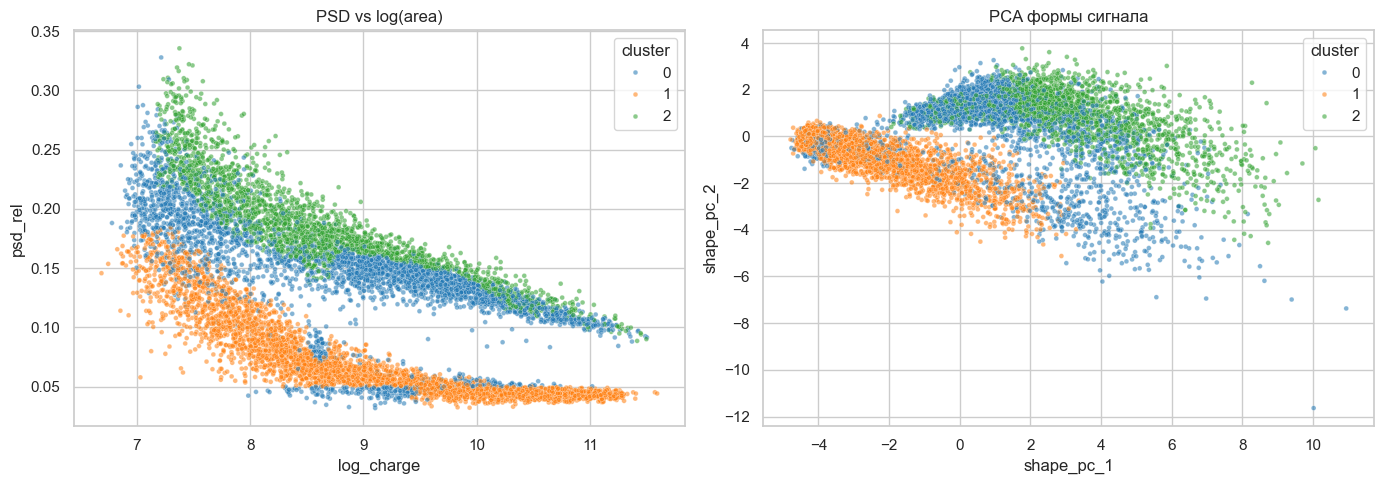

In [7]:
summary = diagnostic.groupby("cluster").agg(
    n=("psd_rel", "size"),
    log_charge=("log_charge", "mean"),
    log_peak=("log_peak", "mean"),
    psd=("psd_rel", "mean"),
    centroid=("centroid", "mean"),
    expected_frac=("expected_frac", "mean"),
)
display(summary)

plot_df = diagnostic.sample(9000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=plot_df, x="log_charge", y="psd_rel", hue="cluster", palette="tab10", s=12, alpha=0.55, ax=axes[0])
axes[0].set_title("PSD vs log(area)")
sns.scatterplot(data=plot_df, x="shape_pc_1", y="shape_pc_2", hue="cluster", palette="tab10", s=12, alpha=0.55, ax=axes[1])
axes[1].set_title("PCA формы сигнала")
plt.tight_layout()
plt.show()

## Итоговые выводы

1. PSD и признаки формы являются наиболее полезными для разделения сигналов.
2. Базовая PCA/PSD-модель хорошо задаёт общую структуру кластеров.
3. GMM полезна как дополнительный вероятностный взгляд на форму импульса.
4. Итоговый `submission.csv` создаётся полностью воспроизводимо из исходного файла `Run200_Wave_0_1.txt`.
5. Кластер `2` интерпретируется как группа неоднозначных, смешанных или аномальных событий.

## Скриншот результата Kaggle

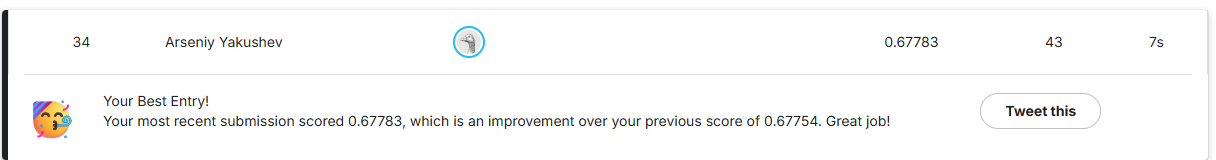